<a href="https://colab.research.google.com/github/JunoJames-JJ/Deep-Learning---TensorFlow/blob/main/TensorFlow_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning for Brain Tumor Classification: Comparing CNN, Transfer Learning, and Vision Transformer**
--------------------------------------------------------------------------------
## **INFO-6152 Deep Learning with TensorFlow & Keras 2**
### **Submitted To: Mohammad Noorchenarboo**
### **Submitted By: Juno Vattakavil James**
### **Project Objective:**

The objective of this project is to develp a deep learning model for classifying brain MRI imags into four categories: Glioma, Meningioma, Pituitary, and No Tumor. This project compares 3 deep learning architectures a Basic CNN, Transfer Learning, and a Vision Transformer to evaluate their classification performance, training efficiency, and robustness. The goal is to understand the strengths and limitations of each architecture and to apply the deep learning concpts learned throughout the course.

--------------------------------------------------------------------------------





### **Project Introduction:**

#### **Project Background:**

A brain tumor is an abnormal growth of cells in the brain. It can affect the normal function of brain and may become danger to life, if its not treatd early. MRI is one of the most common medical imaging techniques used to detect brain tumors because it provides clear and detailed images of the brain.

#### **Motivation:**

Early detection of brain tumors is very important because it helps doctors to provide the right treatment as soon as possible. Deep learning has shown excellent performances in medical image classification and can support doctors by identifying different types of brain tumors from MRI images.


#### **Problem Statement:**

Classifyng MRI images manually takes time and requires experienced medical professionals. The goal of this project is to build deep learning models that can automatically classify brain MRI images into four classes: Glioma, Meningioma, Pituitary, and No Tumor.

#### **Dataset:**

This project uses the MRI Dataset by Masoud Nickparvar from Kaggle. The dataset contains 7,200 MRI images divided into four classes: Glioma, Meningioma, Pituitary, and No Tumor.


#### **Project Overview:**

In this project, 3 deep learning architectures will be implemented and compared. First, a Basic CNN will be built from scratch to learn image features. Next, a Transfer Learning model will use a pre-trained CNN to improve performance. Finally, a Vision Transformer will be implemented to compare a modern transformer based approach with CNN-based models. The models will be evaluated and compared based on its accuracy, training performance, and overall classification results.

--------------------------------------------------------------------------------



In [ ]:
# =====================================================================================================================
# Importing Libraries
# =====================================================================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# =====================================================================================================================
# Downloading the dataset from kaggle
# =====================================================================================================================
import kagglehub

dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
# =====================================================================================================================
# Looking in to the dataset paths
# =====================================================================================================================
train_dir = os.path.join(dataset_path, "Training")
test_dir = os.path.join(dataset_path, "Testing")

print("Dataset Path:", dataset_path)
print("Training Folder Exists:", os.path.exists(train_dir))
print("Testing Folder Exists:", os.path.exists(test_dir))

Dataset Path: /kaggle/input/brain-tumor-mri-dataset
Training Folder Exists: True
Testing Folder Exists: True


In [ ]:
# =====================================================================================================================
# Exploring the dataset, it helps to understand the num of classes and the distribution of images in the training and testing datasets.
# =====================================================================================================================
train_class = os.listdir(train_dir)
test_class = os.listdir(test_dir)
print("Training Dataset")
print("-" * 30)

for cls in sorted(train_class):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count} images")

print("\n Testing Dataset")
print("-" * 30)

for cls in sorted(test_class):
    count = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls}: {count} images")

Training Dataset
------------------------------
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images

 Testing Dataset
------------------------------
glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images


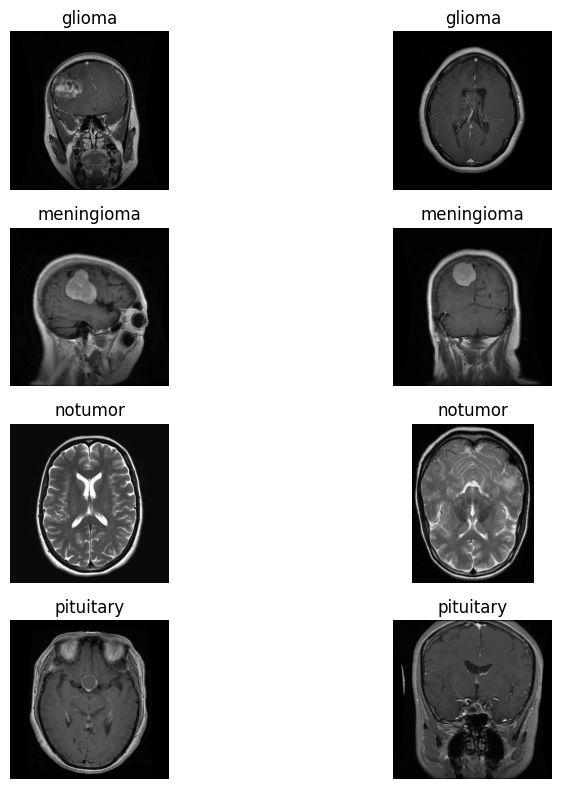

In [ ]:
# =====================================================================================================================
# Trying to display sample image from each class in the training dataset.
# It helps to understand the visual differences between the 4 categories before preprocessing and model training.
# =====================================================================================================================
import random
from PIL import Image

clases = sorted(os.listdir(train_dir))
plt.figure(figsize=(10, 8))
plot_index = 1

for class_name in clases:
    class_path = os.path.join(train_dir, class_name)
    image_names = random.sample(
        os.listdir(class_path),
        2
    )

    for image_name in image_names:
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)
        plt.subplot(4, 2, plot_index)
        plt.imshow(image, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================================================================
# Trying to understand the properties of the image, here, checks their size and color mode.
# It helps to understand whether the images have a consistent format before preprocessing.
# =====================================================================================================================
print("Sample Image Information")
print("-" * 40)

for i in range(10):
    class_name = random.choice(os.listdir(train_dir))
    class_path = os.path.join(train_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    image = Image.open(image_path)

    print(f"image {i+1}")
    print(f"class : {class_name}")
    print(f"size  : {image.size}")
    print(f"mode  : {image.mode}")
    print("-" * 40)


Sample Image Information
----------------------------------------
image 1
class : meningioma
size  : (512, 512)
mode  : RGB
----------------------------------------
image 2
class : notumor
size  : (225, 225)
mode  : RGB
----------------------------------------
image 3
class : meningioma
size  : (512, 512)
mode  : RGB
----------------------------------------
image 4
class : pituitary
size  : (512, 512)
mode  : L
----------------------------------------
image 5
class : glioma
size  : (512, 512)
mode  : L
----------------------------------------
image 6
class : meningioma
size  : (512, 512)
mode  : RGB
----------------------------------------
image 7
class : notumor
size  : (236, 236)
mode  : RGB
----------------------------------------
image 8
class : notumor
size  : (276, 326)
mode  : RGB
----------------------------------------
image 9
class : glioma
size  : (512, 512)
mode  : RGB
----------------------------------------
image 10
class : meningioma
size  : (512, 512)
mode  : RGB
------

#### **Dataset Observations:**

The dataset contains 4 classes: glioma, meningioma, pituitary, and no tumor. The training and testing datasets are balanced with the same number of images in each class, and theswe MRI images have different image sizes. Also, dataset contains both RGB and grayscale images. The images will be resized and converted to a common format during preprocesing before training the models.

### **Data Preprocessing**

In [ ]:
#=====================================================================================================================
# Loading the dataset, for training and testing images using tensorflow
# images are resized to 224 × 224
# converts them to RGB
# then creates batches of 32 images
# =====================================================================================================================
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

IMAGE_SIZE= (224, 224)
BATCH_SIZE= 32
VALIDATION_SPLIT= 0.2
SEED= 42

# load training, validation datasets
train_dataset = image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

validation_dataset = image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

# load testing dataset
test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [ ]:
#=====================================================================================================================
# verify the loaded dataset. here, verify that the images have been loaded correctly.
# also check the class names, image shape, label shape, and batch size before proceeding with preprocessing.
#=====================================================================================================================
print("Classed Names:")
print(train_dataset.class_names)

# getting one batch of images and labels
for images, labels in train_dataset.take(1):

    print("\n Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)

    print("\n Image data type :", images.dtype)
    print("Label data type :", labels.dtype)

Classed Names:
['glioma', 'meningioma', 'notumor', 'pituitary']

 Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)

 Image data type : <dtype: 'float32'>
Label data type : <dtype: 'int32'>


#### **Preprocessing Observations**

The dataset loaded successfully using tenorflow. All images were resized to 224 × 224 pixels. Imags were converted to RGB with 3 color channels, and training data was loaded in batches of 32 images. The class labels were assigned automatically by tensorflow.

In [ ]:
#=====================================================================================================================
# normalize the aimges now, 0-255 to 0.0 - 1.0.
# this change helps the models to train faster and improves training stability.
#=====================================================================================================================
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_dataset.map(lambda images, labels: (normalization_layer(images), labels))
validation_ds = validation_dataset.map(lambda images, labels: (normalization_layer(images), labels))
test_ds = test_dataset.map(lambda images, labels: (normalization_layer(images), labels))

In [ ]:
#=====================================================================================================================
# just verifying the image normalization
#=====================================================================================================================
for images, labels in train_ds.take(1):

    print("Min Pixel Val :", tf.reduce_min(images).numpy())
    print("Max Pixel Val :", tf.reduce_max(images).numpy())

Min Pixel Val : 0.0
Max Pixel Val : 1.0


In [ ]:
#=====================================================================================================================
# Data augmentation, which creates diffrnt versions of the training images by applying small random changes.
# It helped the model learn better, reduces overfitting, and improves its performance on new images.
#=====================================================================================================================
data_augmntation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
#=====================================================================================================================
# Prefetching dataset, it improves the training performance by preparing the next batch of images while the current batch is being processed.
# it helps to reduce the waiting time during model training.
#=====================================================================================================================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

#### **Preprocessing Summary**

The dataset prepared before training the deep learning models. All images were resized to 224 × 224 pixels and convertd to RGB format for consistency. The training data was split into training and validation set. Pixel values were normalized from 0 - 255 to 0 - 1, and a data augmentation pipeline was created to reduce overfitting. Finaly, prefetching was used to improve the data loading performance during training.

### **Building Model 1: Basic CNN Architecture**

A basic CNN is built from scratch to classify the brain MRI images. The convolution layers learn important image features such as edges, shapes, and tumor patterns. Pooling layers reduce the image size, and the final dense layer predicts one of the 4 classes.

In [ ]:
#=====================================================================================================================
# Building basic CNN model
#=====================================================================================================================
basic_cnn_model = tf.keras.Sequential([

    tf.keras.Input(shape=(224, 224, 3)),
    # applying data augmentation only during training
    data_augmntation,
    # convolution blocks
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),

    # added to reduce overfitting
    tf.keras.layers.Dropout(0.5),
    # final output layer for 4 classes
    tf.keras.layers.Dense(4, activation="softmax")
])

basic_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#=====================================================================================================================
# compile the basic CNN model, its compiled using the Adam optimizer and sparse categorical cross-entropy loss.
# Accuracy is used to measure how many images are classified correctly.
#=====================================================================================================================
basic_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
#=====================================================================================================================
# Training the basic CNN, its trained using the training dataset and checked using the validation dataset after each epoch.
# The training time is recorded so it can be compared with the other models.
#=====================================================================================================================
import time

EPOCHS = 15
start_time = time.time()
basic_cnn_history = basic_cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

basic_cnn_training_time = time.time() - start_time
print(
    f"\n Basic CNN Training Time: "
    f"{basic_cnn_training_time:.2f} seconds"
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.3596 - loss: 1.4904 - val_accuracy: 0.3661 - val_loss: 1.4752
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.5266 - loss: 1.0705 - val_accuracy: 0.4107 - val_loss: 1.5143
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.5969 - loss: 0.9610 - val_accuracy: 0.4437 - val_loss: 1.2761
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.6275 - loss: 0.8913 - val_accuracy: 0.4054 - val_loss: 1.5942
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.6580 - loss: 0.8209 - val_accuracy: 0.5446 - val_loss: 1.3226
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.7025 - loss: 0.7556 - val_accuracy: 0.6687 - val_loss: 0.8657
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.7158 - loss: 0.7203 - val_accuracy: 0.6607 - val_loss: 0.8687
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.7228 - loss: 0.7025 - v

#### **Basic CNN Training Observation**

The Basic CNN reached 78.68% training accuracy and 70.45% validation accuracy after 15 epochs. The training accuracy increased steadily throughout the training process, while the validation accuracy fluctuated between epochs. It shows that the model learnd the training data well but showed some instability in generalizing to the validation data.

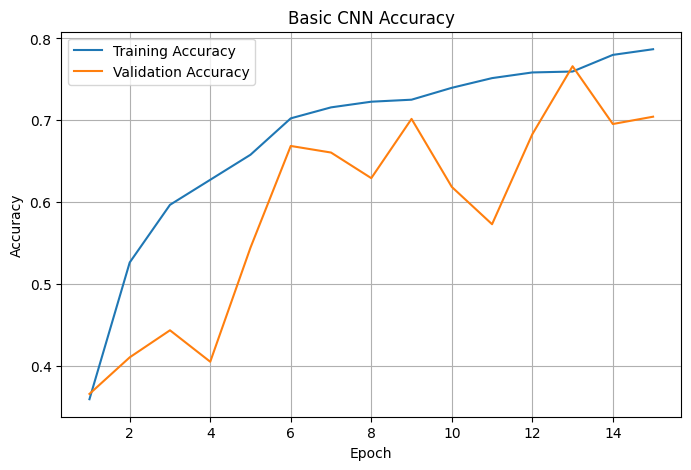

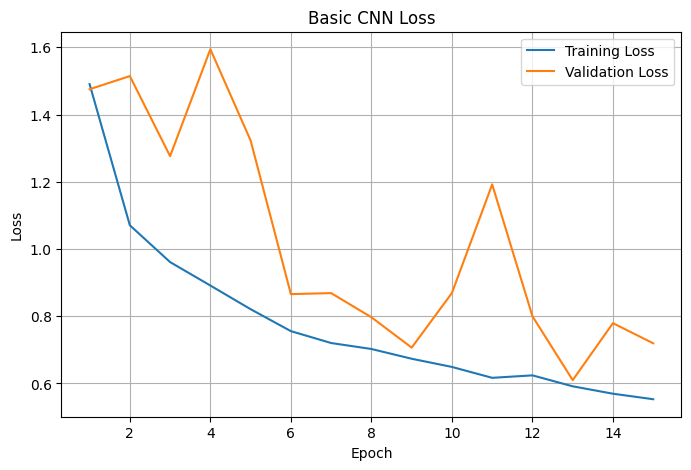

In [ ]:
#=====================================================================================================================
# Plotting basic CNN model
#=====================================================================================================================
training_acuracy = basic_cnn_history.history["accuracy"]
validation_acuracy = basic_cnn_history.history["val_accuracy"]

training_loss = basic_cnn_history.history["loss"]
validation_loss = basic_cnn_history.history["val_loss"]

epochs_range = range(1, EPOCHS + 1)

# accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_acuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_acuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# loss curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Basic CNN Loss")
plt.legend()
plt.grid(True)
plt.show()

#### **Basic CNN Performance Observation**

The Basic CNN showed a steady increase in training accuracy and a gradual decreas in training loss over the 15 epochs. However, the validation accuracy and validation loss fluctuated throughout training, showing an inconsistent performance on the validation dataset. These results shows that the model learned the training data well but has a limited generalization to unseen MRI images.

In [ ]:
#=====================================================================================================================
# evaluating thebasic CNN on test dataset
#=====================================================================================================================
basic_cnn_test_loss, basic_cnn_test_accuracy = basic_cnn_model.evaluate(test_dataset)

print(f"\n Test loss: {basic_cnn_test_loss:.4f}")
print(f"\n Test accuracy: {basic_cnn_test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.6594 - loss: 1.1387

 Test loss: 1.1387

 Test accuracy: 65.94%


#### **Basic CNN Test Observation**

The Basic CNN showed a test accuracy of 65.94%. The test accuracy is lower than the training and validation accuracy, showing that the model had difficulty in generalizing to unseen images. This model serves the baseline for comparing the transfer learning and vision transformer models.

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step


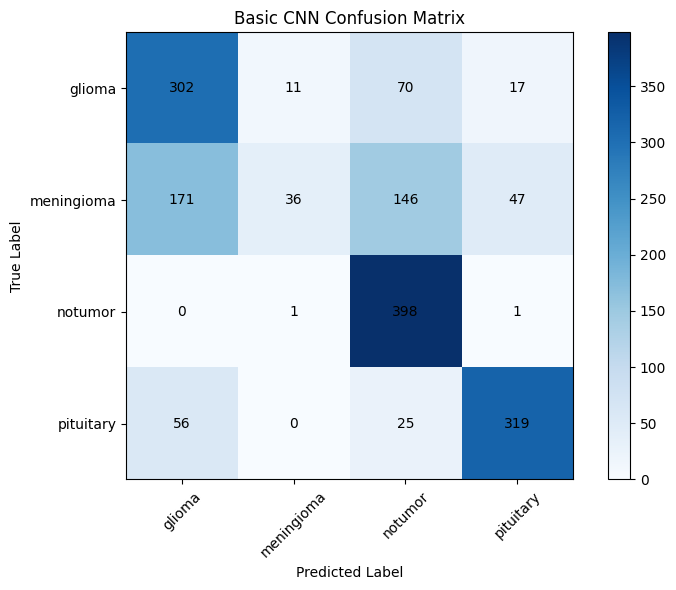

In [ ]:
#=====================================================================================================================
# confusion matrix
#=====================================================================================================================
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# predictions
predictions = basic_cnn_model.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)
# get true labels
true_labels = np.concatenate([labels for images, labels in test_dataset])
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Basic CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

class_names = test_dataset.class_names
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

#### **Confusion Matrix Observation**

The Basic CNN classified the No tumor class, most accurately. Its also performed reasonably well on the Glioma and Pituitary classes. However, the model struggled to classify the Meningioma class, with many Meningioma images being incorrectly predicted as Glioma and Notumor. This shows that the model had difficulty distinguishing between similar tumor types.

In [ ]:
#=====================================================================================================================
# Classification report, provides precision, recall, F1-score, and support for each class
# they help evaluate how well the model performs for every brain tumor category.
#=====================================================================================================================
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.57      0.76      0.65       400
  meningioma       0.75      0.09      0.16       400
     notumor       0.62      0.99      0.77       400
   pituitary       0.83      0.80      0.81       400

    accuracy                           0.66      1600
   macro avg       0.69      0.66      0.60      1600
weighted avg       0.69      0.66      0.60      1600



#### **Classification Report Observation**

Basic CNN performed well in classifying the No tumor and Pituitary classes, achieving high recall values. However, the model showed lower performance for the Glioma and especially the Meningioma classes. The overall test accuracy was 66.00%, with a macro F1-score of 0.60. These results provide a baseline for comparison with the transfer learning and vision transformer models.

In [ ]:
#=====================================================================================================================
# Overall model comparison, performance of all 3 deep learning models will be compared using the same evaluation metrics.
# This comparison will help identify the best model for brain tumor classification.
#=====================================================================================================================
import pandas as pd
comparisn_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Precision (Macro Avg)",
        "Recall (Macro Avg)",
        "F1-Score (Macro Avg)",
        "Training Time (s)",
        "Total Params"
    ],
    "Basic CNN": [
        "78.12%",
        "63.13%",
        "66.00%",
        "0.69",
        "0.66",
        "0.60",
        "166.46",
        "110,276"
    ]
})

comparisn_table.set_index("Metric")

,Basic CNN
Metric,
Training Accuracy,78.12%
Validation Accuracy,63.13%
Test Accuracy,66.00%
Precision (Macro Avg),0.69
Recall (Macro Avg),0.66
F1-Score (Macro Avg),0.60
Training Time (s),166.46
Total Params,"110,276"


### **Building Model 2: Transfer Learning**

Transfer learning uses model that was already trained on a large image dataset. Instead of learning all image features from the beginning, the model uses the learned features and adapts them for brain classification. This can improve accuracy and reduce training time.

In [ ]:
#=====================================================================================================================
# Loading pretrained model, like EfficientNetB0
# weights="imagenet" loads learned image features
#=====================================================================================================================
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#=====================================================================================================================
# creating transfer learning architecture, efficientNetB0 model is used as the feature extractor.
# pretrained layers are frozen to preserve the learned image features.
# new classification layers are added to classify the images into the 4 brain tumor classs.
#=====================================================================================================================
transfer_learning_model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    data_augmntation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation="softmax")
])
transfer_learning_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
#=====================================================================================================================
# compiling the transfer learning model, its compiled using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy as the evaluation metric.
#=====================================================================================================================
transfer_learning_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
#=====================================================================================================================
# Early Stopping is a callback, something that runs during training.
# It watches the training process after every epoch.
#=====================================================================================================================
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
#=====================================================================================================================
# Trainig the transfer learning model, its trained using training dataset and validated using the validation dataset.
#=====================================================================================================================
import time

EPOCHS = 15
start_time = time.time()
transfer_learning_history = transfer_learning_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

transfer_learning_training_time = time.time() - start_time
print(f"\n Transfer Learning Training Time: {transfer_learning_training_time:.2f} seconds")

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 129ms/step - accuracy: 0.7529 - loss: 0.6276 - val_accuracy: 0.8080 - val_loss: 0.4816
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.8315 - loss: 0.4360 - val_accuracy: 0.8321 - val_loss: 0.4152
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.8504 - loss: 0.3889 - val_accuracy: 0.8714 - val_loss: 0.3220
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.8687 - loss: 0.3490 - val_accuracy: 0.8875 - val_loss: 0.2982
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.8685 - loss: 0.3409 - val_accuracy: 0.8643 - val_loss: 0.3302
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.8859 - loss: 0.3029 - val_accuracy: 0.9062 - val_loss: 0.2483
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.8893 - loss: 0.2891 - val_accuracy: 0.8741 - val_loss: 0.2998
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.8942 - loss: 0.

#### **Transfer Learning Training Observation**

TTransfer Learning model learned th images effectively. The training and validation accuracy increased steadily, while the training and validation loss generally decreased. Early stopping automatically stopped the training after 9 epochs because the validation loss did not improve for three consecutive epochs, which helped avoid unecessary training and reduced the risk of overfitting. The model achieved 90.02% training accuracy and 89.38% validation accuracy, showing a significant improvemnt over the Basic CNN.

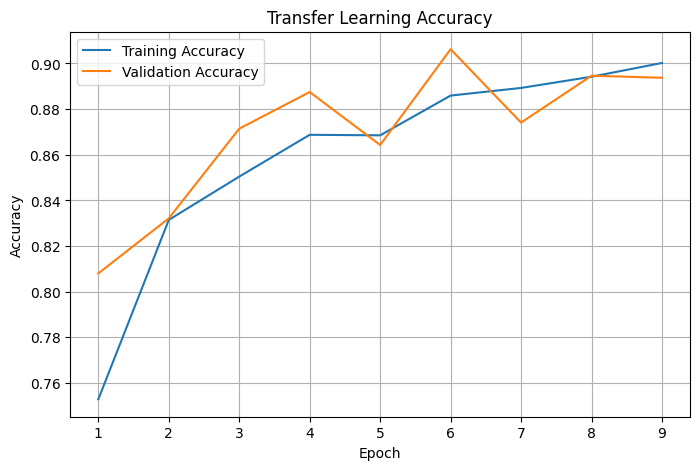

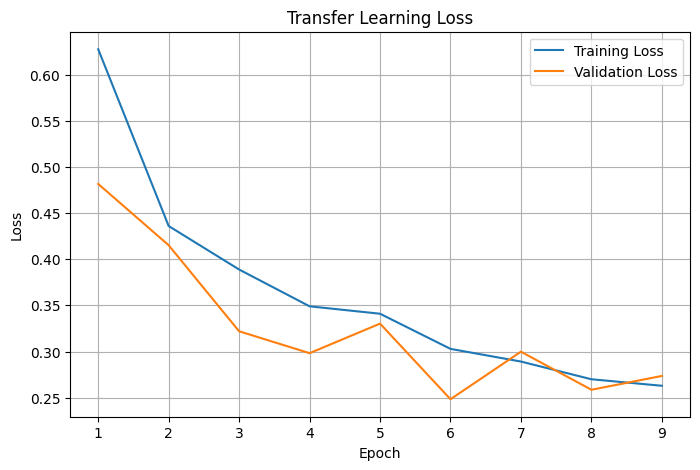

In [ ]:
#=====================================================================================================================
# Plotting transfer learning training curves
#=====================================================================================================================
training_accuracy = transfer_learning_history.history["accuracy"]
validation_accuracy = transfer_learning_history.history["val_accuracy"]
training_loss = transfer_learning_history.history["loss"]
validation_loss = transfer_learning_history.history["val_loss"]
# early stopping stopped after 11 epochs, not 15.
epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()
plt.grid(True)
plt.show()

#### **Transfer Learning Performance Observation**

Transfer Learning model learned MRI images effectively. Both training and validation accuracy increased during training, while then training and validation loss generally decreased. Validation curves remained close to the training curves, with only minor fluctuations, showing good generalization and minimal overfitting. Early stopping automatically stopped the training after 9 epochs because the validation loss didnt improve for 3 consecutive epochs, and the best model weights were restored automatically.

In [ ]:
#=====================================================================================================================
# Evaluating transfer learning model, it's evaluated on the unseen test dataset to measure its performance on new images.
#=====================================================================================================================
transfer_learning_test_loss, transfer_learning_test_accuracy = transfer_learning_model.evaluate(test_dataset)

print(f"\nTest Loss: {transfer_learning_test_loss:.4f}")
print(f"Test Accuracy: {transfer_learning_test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.8456 - loss: 0.4939

Test Loss: 0.4939
Test Accuracy: 84.56%


#### **Transfer learning test observation**

Transfer learning model achieved a test accuracy of 84.56%, which is signifcantly higher than the basic CNN. The test accuracy is close to the training and validation accuracy, showing that the model generalized well to unseen images. These results shows that using the pretrained EfficientNetB0 feature extractor significantly improved the classification performance.

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step


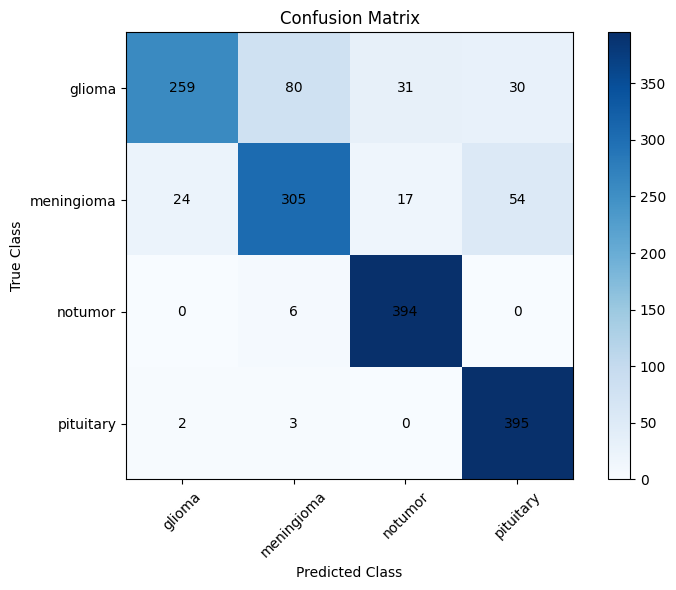

In [ ]:
#=====================================================================================================================
# confusion matrix
#=====================================================================================================================
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

predictions = transfer_learning_model.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.concatenate([labels for images, labels in test_dataset])
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
class_names = test_dataset.class_names

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

#### **Confusion Matrix Observation**

Transfer Learning model classified the No tumor and Pituitary classes with very high accuracy. It also performed well on the Meningioma class and most of the misclas\sifications occurred between the Glioma and Meningioma classs, showing that these two tumor types were more difficult to distinguish. Overall, the confusion matrix shows a significant improvement over the Basic CNN.

In [ ]:
#=====================================================================================================================
# classification report
#=====================================================================================================================
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.91      0.65      0.76       400
  meningioma       0.77      0.76      0.77       400
     notumor       0.89      0.98      0.94       400
   pituitary       0.82      0.99      0.90       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.84      1600
weighted avg       0.85      0.85      0.84      1600



#### **Transfer Learning classification report bbservation**

Transfer Learning model performd well across all 4 classes. Its performed particularly well on the Notumor and Pituitary classes, while also maintaining good performance on the Glioma and Meningioma classes. The model achieved an overall test accuracy of 85% with a macro F1-score of 0.84, showng a clear improvement over the Basic CNN.

In [ ]:
#=====================================================================================================================
# Overall model comparison,
#=====================================================================================================================
import pandas as pd

comparison_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Precision (Macro Avg)",
        "Recall (Macro Avg)",
        "F1-Score (Macro Avg)",
        "Training Time (s)",
        "Total Params"
    ],
    "Basic CNN": [
        "78.12%",
        "63.13%",
        "66.00%",
        "0.69",
        "0.66",
        "0.60",
        "166.46",
        "110,276"
    ],
    "Transfer Learning": [
        "90.02%",
        "89.38%",
        "84.56%",
        "0.85",
        "0.85",
        "0.84",
        "167.10",
        "4,214,055"
    ]
})

comparison_table

,Metric,Basic CNN,Transfer Learning
0,Training Accuracy,78.12%,90.02%
1,Validation Accuracy,63.13%,89.38%
2,Test Accuracy,66.00%,84.56%
3,Precision (Macro Avg),0.69,0.85
4,Recall (Macro Avg),0.66,0.85
5,F1-Score (Macro Avg),0.60,0.84
6,Training Time (s),166.46,167.10
7,Total Params,"110,276","4,214,055"


### **Building Model 3: Vision Transfer**

Vision transformer is a deep learning model that uses the transformer architecture for image classification, instead of using convolutional layers like CNNs, ViT divides an image into small patches and learns the relationships between them using a self-attention mechanism, which allows the model to capture both local and global image features effectively.

In [ ]:
#=====================================================================================================================
# Checkding pretrained ViT models
#=====================================================================================================================
import keras_hub

print(keras_hub.models.ViTImageClassifier.presets.keys())

dict_keys(['vit_base_patch16_224_imagenet', 'vit_base_patch16_384_imagenet', 'vit_large_patch16_224_imagenet', 'vit_large_patch16_384_imagenet', 'vit_base_patch32_384_imagenet', 'vit_large_patch32_384_imagenet', 'vit_base_patch16_224_imagenet21k', 'vit_base_patch32_224_imagenet21k', 'vit_huge_patch14_224_imagenet21k', 'vit_large_patch16_224_imagenet21k', 'vit_large_patch32_224_imagenet21k'])


In [ ]:
#=====================================================================================================================
# Loading the pretrained vision transformer
# A pre-trained vision transformer (ViT) model is loaded from KerasHub.
# The model was pre-trained on the ImageNet dataset and will be fine-tuned for brain mri tumor classification.
#=====================================================================================================================
from keras import layers
import keras_hub
import tensorflow as tf

vit_back = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet")
vit_back.trainable = False
inputs = tf.keras.Input(shape=(224, 224, 3))

x = vit_back(inputs)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation="softmax")(x)

vit_model = tf.keras.Model(inputs, outputs)
vit_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         3,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,801,732 (327.31 MB)

 Trainable params: 3,076 (12.02 KB)

 Non-trainable params: 85,798,656 (327.30 MB)

In [ ]:
#=====================================================================================================================
# Freezing the pretrained ViT backbone, it keeps its learned features, and only final clasification layer learns the dataset.
#=====================================================================================================================
vit_back.trainable = False
vit_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         3,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,801,732 (327.31 MB)

 Trainable params: 3,076 (12.02 KB)

 Non-trainable params: 85,798,656 (327.30 MB)

In [ ]:
#=====================================================================================================================
# compiling ViT model
#=====================================================================================================================
vit_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
#=====================================================================================================================
# added early stopping added
#=====================================================================================================================
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
#=====================================================================================================================
# Training ViT model
#=====================================================================================================================
import time

EPOCHS = 15
start_time = time.time()
vit_history = vit_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

vit_training_time = time.time() - start_time
print(f"\nVision Transformer Training Time: {vit_training_time:.2f} seconds")

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 595ms/step - accuracy: 0.4902 - loss: 1.1381 - val_accuracy: 0.7080 - val_loss: 0.8934
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 564ms/step - accuracy: 0.6339 - loss: 0.9280 - val_accuracy: 0.7152 - val_loss: 0.7968
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 561ms/step - accuracy: 0.6920 - loss: 0.8264 - val_accuracy: 0.7304 - val_loss: 0.7368
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 561ms/step - accuracy: 0.7042 - loss: 0.7793 - val_accuracy: 0.7759 - val_loss: 0.6856
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 559ms/step - accuracy: 0.7176 - loss: 0.7440 - val_accuracy: 0.7964 - val_loss: 0.6471
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 561ms/step - accuracy: 0.7257 - loss: 0.7269 - val_accuracy: 0.7946 - val_loss: 0.6425
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 561ms/step - accuracy: 0.7246 - loss: 0.7107 - val_accuracy: 0.7848 - val_loss: 0.6201
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 559ms/step - accuracy: 0.7395 - loss: 

#### **Vision Transformer Training Observation**

Vision Transformer learned the images gradually during training. The training and validation accuracy improved during 15 epochs, while the training and validation loss generally decreased. The model achieved 75% training accuracy and 82.14% validation accuracy. Although it required a much longer training time 1197.49 seconds than the other models, it showed stable learning and good generalization.

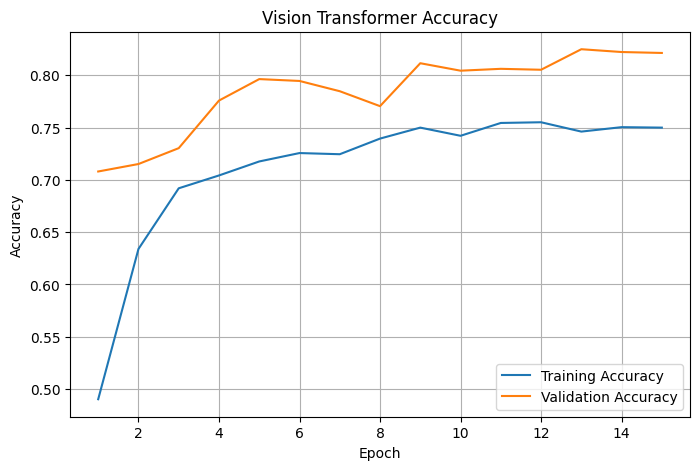

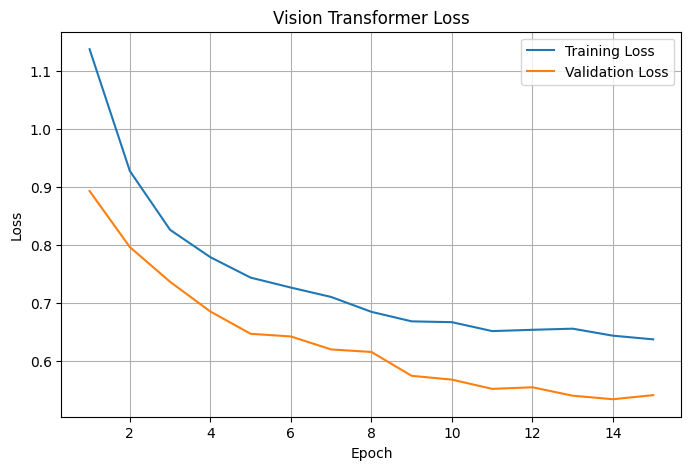

In [ ]:
#=====================================================================================================================
# Plotting
#=====================================================================================================================
training_accuracy = vit_history.history["accuracy"]
validation_accuracy = vit_history.history["val_accuracy"]
training_loss = vit_history.history["loss"]
validation_loss = vit_history.history["val_loss"]
epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Vision Transformer Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vision Transformer Loss")
plt.legend()
plt.grid(True)
plt.show()

#### **Vision Transformer Training Observation**

Vision Transformer showed a steady increase in both training and validation accuracy, while the training and validation loss gradually decreased throughout the training process. The validation curves remained consistently higher than the training curves, shwoing good generalization with no significant signs of overfitting. However, the model required a much longer training time than the Basic CNN and Transfer Learning models.

In [ ]:
#=====================================================================================================================
# Evaluate Vit
#=====================================================================================================================
vit_test_loss, vit_test_accuracy = vit_model.evaluate(test_dataset)
print(f"\nTest Loss: {vit_test_loss:.4f}")
print(f"Test Accuracy: {vit_test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 481ms/step - accuracy: 0.7000 - loss: 0.8864

Test Loss: 0.8864
Test Accuracy: 70.00%


50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 442ms/step


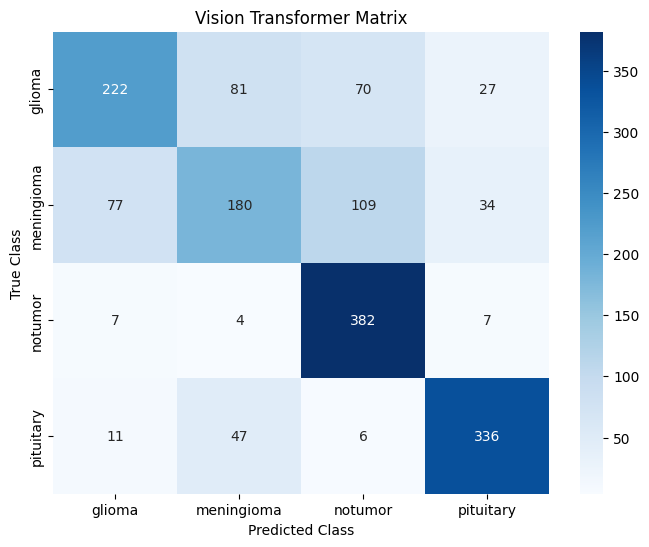

In [ ]:
#=====================================================================================================================
# Confusion matrix
#=====================================================================================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred = vit_model.predict(test_dataset)
y_pred = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Vision Transformer Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

#### **Confusion Matrix Observation**

Vision Transformer achieved a test accuracy of 70%, showing moderate performance on the unseen images. It classified the no tumor and pituitary classes well but have difficulty in distinguishing between the glioma and meningioma classes, resulting in several misclasifications. Overall, the vision transformer performed better than the basic CNN but did not achieve the same level of performance as the transfer learning model.

In [ ]:
#=====================================================================================================================
# classification report
#=====================================================================================================================
from sklearn.metrics import classification_report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.70      0.56      0.62       400
  meningioma       0.58      0.45      0.51       400
     notumor       0.67      0.95      0.79       400
   pituitary       0.83      0.84      0.84       400

    accuracy                           0.70      1600
   macro avg       0.70      0.70      0.69      1600
weighted avg       0.70      0.70      0.69      1600



#### **Vision Transformer report observation**

Vision Transformer achieved an overall 70% test accuracy, with macro average precision of 0.70, recall of 0.70, and F1-score of 0.69. It performed best on the Pituitary and Notumor classes, while the Glioma and Meningioma classes were more difficult to classify. Overall, the model showed balanced performance across the clases but didnt perform as well as the transfer learning model.

In [ ]:
#=====================================================================================================================
# overall model comparison,
#=====================================================================================================================
import pandas as pd

comparison_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Precision (Macro Avg)",
        "Recall (Macro Avg)",
        "F1-Score (Macro Avg)",
        "Training Time (s)",
        "Total Parameters"
    ],

    "Basic CNN": [
        "78.12%",
        "63.13%",
        "59.69%",
        "0.46",
        "0.60",
        "0.51",
        "166.46",
        "110,276"
    ],

    "Transfer Learning": [
        "90.02%",
        "89.38%",
        "84.56%",
        "0.85",
        "0.85",
        "0.84",
        "167.10",
        "4,214,055"
    ],

    "Vision Transformer": [
        "75.00%",
        "82.14%",
        "70.00%",
        "0.70",
        "0.70",
        "0.69",
        "1197.49",
        "85,801,732"
    ]
})

comparison_table

#### **Conclusion**

Used 3 models and those were successfully implemented and evaluated on the brain MRI dataset. Transfer Learning produced the best overall performance, while the Basic CNN served as the baseline and the Vision Transformer demonstrated reasonable performance with a much larger model size and longer training time.